In [1]:
#Imports

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from collections import Counter

In [2]:
#Dataset_Path

data_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_color")

In [3]:
total_images = 0

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
    if class_path.is_dir():
        num_images = len(os.listdir(class_path))
        total_images += num_images

print("Total Images:", total_images)

Total Images: 54305


In [4]:
#Exploratory Data Analysis(EDA)
#Class Distribution

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    if class_path.is_dir():
        class_counts[class_name] = len(os.listdir(class_path))

# Print counts
for k, v in class_counts.items():
    print(f"{k}: {v}")

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 1909
Tomato___Leaf_Mold

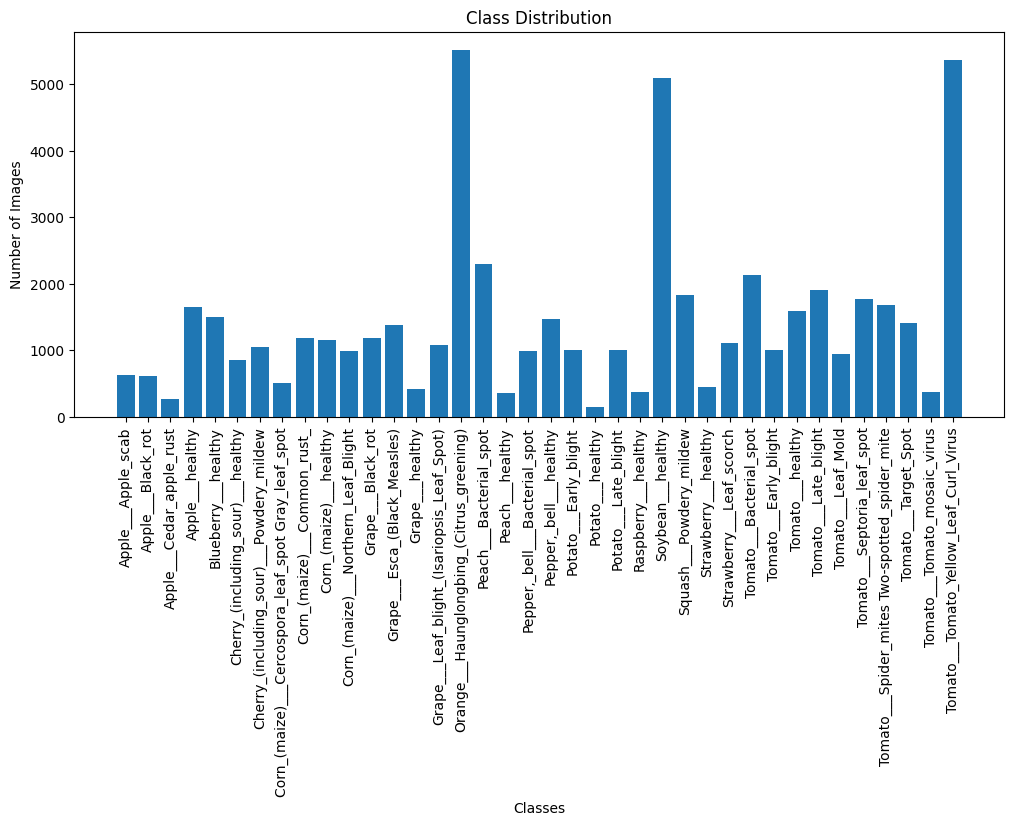

In [5]:
#Plot Class Distribution

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

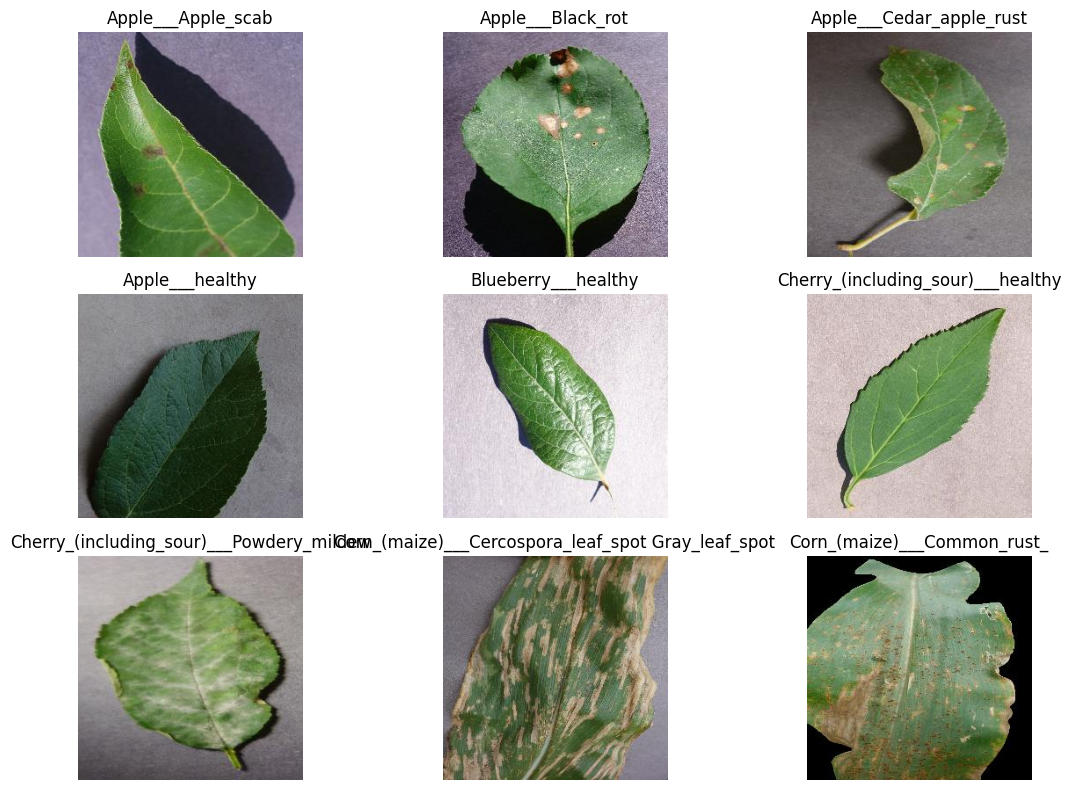

In [6]:
#Sample Image Visualization


plt.figure(figsize=(12,8))

classes = list(class_counts.keys())

for i, class_name in enumerate(classes[:9]):  # first 9 classes
    class_path = data_dir / class_name
    img_name = random.choice(os.listdir(class_path))
    img_path = class_path / img_name
    
    img = plt.imread(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#Train/Val/Test Split
#Split Function

import shutil

output_dir = Path(r"C:\Users\Prarthana\Desktop\Crop_Disease_Detection\PlantVillage_split")

train_dir = output_dir / "train"
val_dir   = output_dir / "val"
test_dir  = output_dir / "test"

for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

In [8]:
#Split Code

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
    if not class_path.is_dir():
        continue
    
    images = os.listdir(class_path)
    random.shuffle(images)
    
    total = len(images)
    train_end = int(train_ratio * total)
    val_end   = int((train_ratio + val_ratio) * total)
    
    splits = {
        train_dir: images[:train_end],
        val_dir: images[train_end:val_end],
        test_dir: images[val_end:]
    }
    
    for split_dir, split_images in splits.items():
        (split_dir / class_name).mkdir(parents=True, exist_ok=True)
        
        for img in split_images:
            shutil.copy(class_path / img, split_dir / class_name / img)

print("✅ Data Split Done")

✅ Data Split Done


In [9]:
# Preprocessing Pipeline (TensorFlow)
#Load Dataset + Resize + Normalize

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
)

class_names = train_ds.class_names

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 37997 files belonging to 38 classes.
Found 8146 files belonging to 38 classes.
Found 8162 files belonging to 38 classes.


In [10]:
#Normalize + Prefetch

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [11]:
def print_dataset_details(folder, name):
    print(f"\n📂 {name} Folder:")
    
    total = 0
    
    for class_name in os.listdir(folder):
        class_path = folder / class_name
        
        if class_path.is_dir():
            num_images = len(os.listdir(class_path))
            total += num_images
            print(f"{class_name}: {num_images}")
    
    print(f"👉 Total {name} Images: {total}")
print_dataset_details(train_dir, "Train")
print_dataset_details(val_dir, "Validation")
print_dataset_details(test_dir, "Test")


📂 Train Folder:
Apple___Apple_scab: 441
Apple___Black_rot: 434
Apple___Cedar_apple_rust: 192
Apple___healthy: 1151
Blueberry___healthy: 1051
Cherry_(including_sour)___healthy: 597
Cherry_(including_sour)___Powdery_mildew: 736
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 359
Corn_(maize)___Common_rust_: 834
Corn_(maize)___healthy: 813
Corn_(maize)___Northern_Leaf_Blight: 689
Grape___Black_rot: 826
Grape___Esca_(Black_Measles): 968
Grape___healthy: 296
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753
Orange___Haunglongbing_(Citrus_greening): 3854
Peach___Bacterial_spot: 1607
Peach___healthy: 251
Pepper,_bell___Bacterial_spot: 697
Pepper,_bell___healthy: 1034
Potato___Early_blight: 700
Potato___healthy: 106
Potato___Late_blight: 700
Raspberry___healthy: 259
Soybean___healthy: 3563
Squash___Powdery_mildew: 1284
Strawberry___healthy: 319
Strawberry___Leaf_scorch: 776
Tomato___Bacterial_spot: 1488
Tomato___Early_blight: 700
Tomato___healthy: 1113
Tomato___Late_blight: 1336
Tomato___Le